In [7]:
from google.colab import files
files_to_load=files.upload()

Saving Copy of ABC Company.xlsx to Copy of ABC Company.xlsx


In [8]:
import pandas as pd

# Assuming the uploaded file is 'Copy of ABC Company.xlsx'
file_name = 'Copy of ABC Company.xlsx'
df = pd.read_excel(file_name)

# Display the first 5 rows of the DataFrame
display(df.head())

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [9]:
import numpy as np

# Replace the 'Height' column with random numbers between 150 and 180
df['Height'] = np.random.randint(150, 181, size=len(df))

# Display the first 5 rows of the DataFrame to show the updated 'Height' column
display(df.head())

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,162,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,164,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,155,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,177,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,170,231,NaN,5000000.0


In [10]:
# Calculate the distribution of employees across each team
team_distribution = df['Team'].value_counts()

# Calculate the percentage split relative to the total number of employees
total_employees = len(df)
team_percentage = (team_distribution / total_employees) * 100

print("Employee Distribution Across Teams:\n", team_distribution)
print("\nPercentage Split Across Teams:\n", team_percentage.round(2).astype(str) + '%')

Employee Distribution Across Teams:
 Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

Percentage Split Across Teams:
 Team
New Orleans Pelicans    

In [11]:
# Segregate employees based on their positions within the company
position_distribution = df['Position'].value_counts()

print("Employee Distribution by Position:\n", position_distribution)

Employee Distribution by Position:
 Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


In [12]:
# Identify the predominant age group among employees

# First, let's look at the basic statistics of the 'Age' column
print("Age statistics:\n", df['Age'].describe())

# Define age bins and labels for categorization
age_bins = [18, 25, 35, 45, 55, 65, 100] # Assuming a reasonable age range
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

# Create a new column 'Age Group'
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Calculate the distribution of employees across age groups
age_group_distribution = df['Age Group'].value_counts().sort_index()

print("\nEmployee Distribution by Age Group:\n", age_group_distribution)

# Identify the predominant age group
predominant_age_group = age_group_distribution.idxmax()
print(f"\nThe predominant age group among employees is: {predominant_age_group}")

Age statistics:
 count    458.000000
mean      26.934498
std        4.400128
min       19.000000
25%       24.000000
50%       26.000000
75%       30.000000
max       40.000000
Name: Age, dtype: float64

Employee Distribution by Age Group:
 Age Group
18-24    154
25-34    272
35-44     32
45-54      0
55-64      0
65+        0
Name: count, dtype: int64

The predominant age group among employees is: 25-34


In [14]:
# Discover which team and position have the highest salary expenditure

# Before calculating, let's check for missing values in 'Salary' and fill them if necessary
# For salary expenditure, it's reasonable to fill missing salaries with 0 or the mean/median, depending on context.
# Given we want to find highest expenditure, let's fill with 0 so they don't impact the sum positively.
df['Salary'] = df['Salary'].fillna(0)

# Calculate total salary expenditure per team
team_salary_expenditure = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)

# Calculate total salary expenditure per position
position_salary_expenditure = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

print("\nTotal Salary Expenditure per Team:\n", team_salary_expenditure)
print("\nTotal Salary Expenditure per Position:\n", position_salary_expenditure)

highest_team_expenditure = team_salary_expenditure.index[0]
highest_team_salary = team_salary_expenditure.iloc[0]

highest_position_expenditure = position_salary_expenditure.index[0]
highest_position_salary = position_salary_expenditure.iloc[0]

print(f"\nTeam with the highest salary expenditure: {highest_team_expenditure} (Total Salary: ${highest_team_salary:,.2f})")
print(f"Position with the highest salary expenditure: {highest_position_expenditure} (Total Salary: ${highest_position_salary:,.2f})")


Total Salary Expenditure per Team:
 Team
Cleveland Cavaliers       106988689.0
Los Angeles Clippers       94854640.0
Oklahoma City Thunder      93765298.0
Golden State Warriors      88868997.0
Chicago Bulls              86783378.0
San Antonio Spurs          84442733.0
New Orleans Pelicans       82750774.0
Miami Heat                 82515673.0
Charlotte Hornets          78340920.0
Memphis Grizzlies          76550880.0
Washington Wizards         76328636.0
Houston Rockets            75283021.0
New York Knicks            73303898.0
Atlanta Hawks              72902950.0
Los Angeles Lakers         71770431.0
Sacramento Kings           71683666.0
Dallas Mavericks           71198732.0
Toronto Raptors            71117611.0
Milwaukee Bucks            69603517.0
Detroit Pistons            67168263.0
Indiana Pacers             66751826.0
Utah Jazz                  64007367.0
Phoenix Suns               63445135.0
Orlando Magic              60161470.0
Denver Nuggets             60121930.0
Minnesot

Correlation between Age and Salary: 0.21


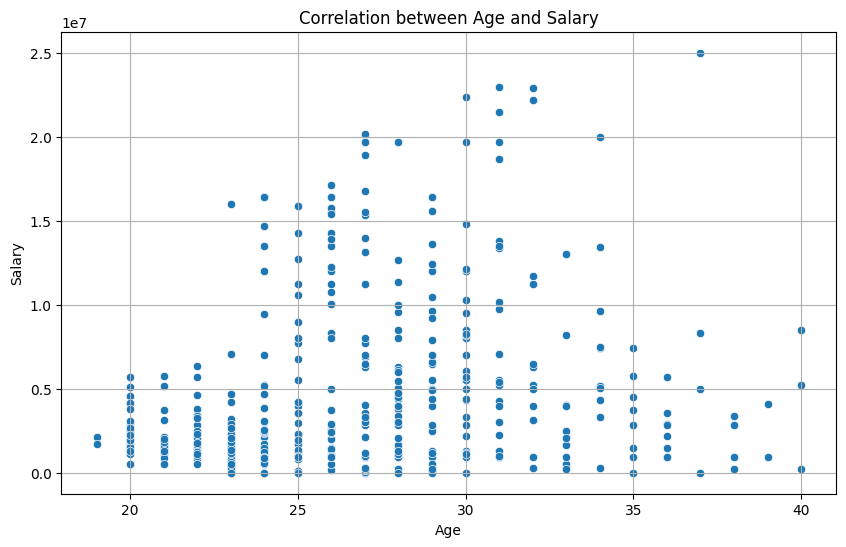

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Investigate if there's any correlation between age and salary

# Calculate the correlation coefficient between 'Age' and 'Salary'
correlation_age_salary = df['Age'].corr(df['Salary'])

print(f"Correlation between Age and Salary: {correlation_age_salary:.2f}")

# Represent it visually using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Salary', data=df)
plt.title('Correlation between Age and Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

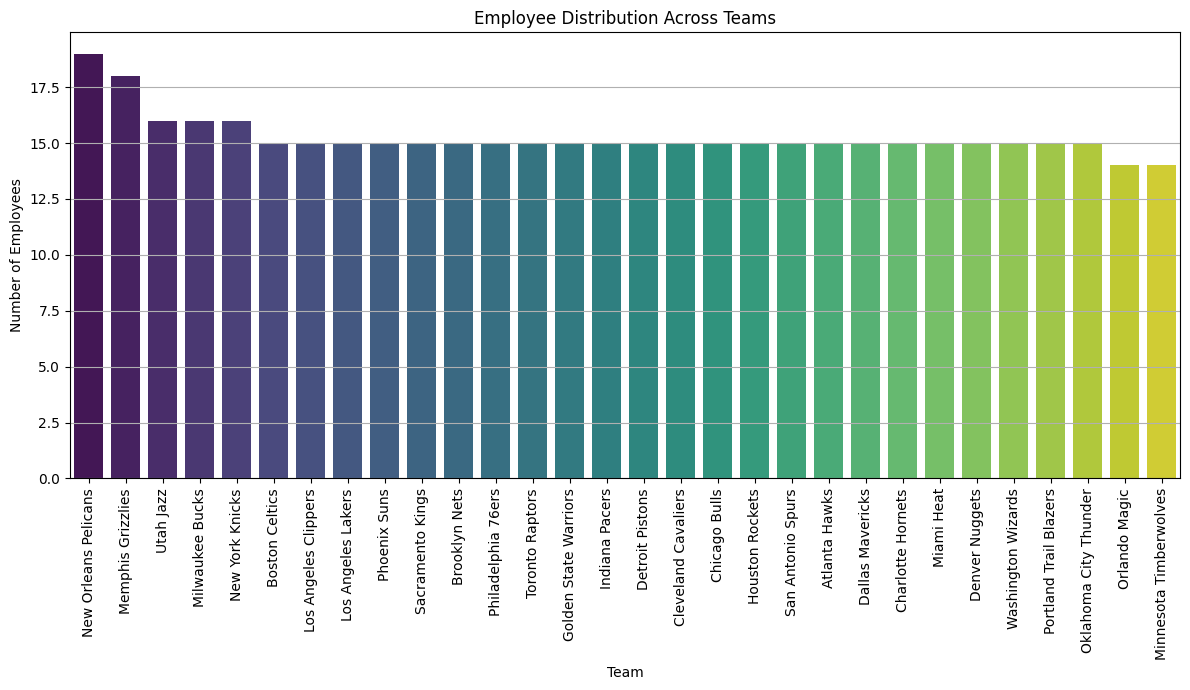

In [17]:
# Visualize the distribution of employees across each team
plt.figure(figsize=(12, 7))
sns.barplot(x=team_distribution.index, y=team_distribution.values, hue=team_distribution.index, palette='viridis', legend=False)
plt.title('Employee Distribution Across Teams')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

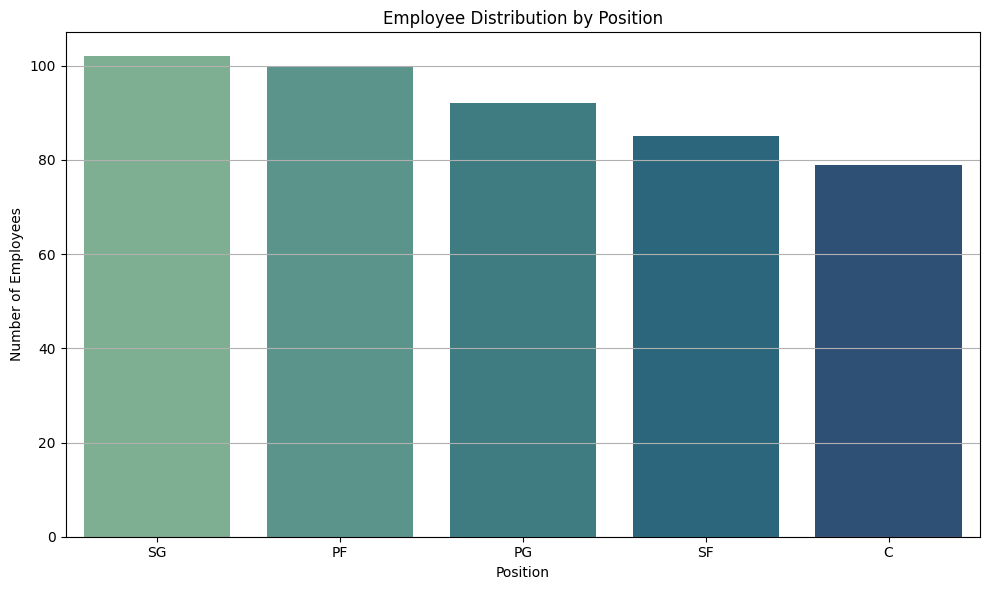

In [18]:
# Visualize employee segregation based on positions
plt.figure(figsize=(10, 6))
sns.barplot(x=position_distribution.index, y=position_distribution.values, hue=position_distribution.index, palette='crest', legend=False)
plt.title('Employee Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

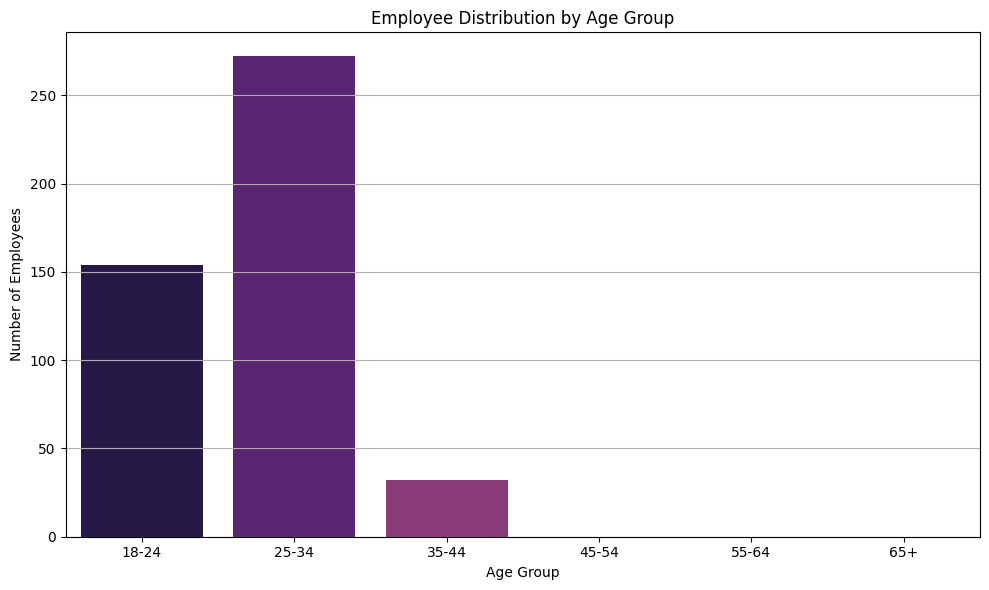

In [19]:
# Visualize the predominant age group
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_distribution.index, y=age_group_distribution.values, hue=age_group_distribution.index, palette='magma', legend=False)
plt.title('Employee Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Employees')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

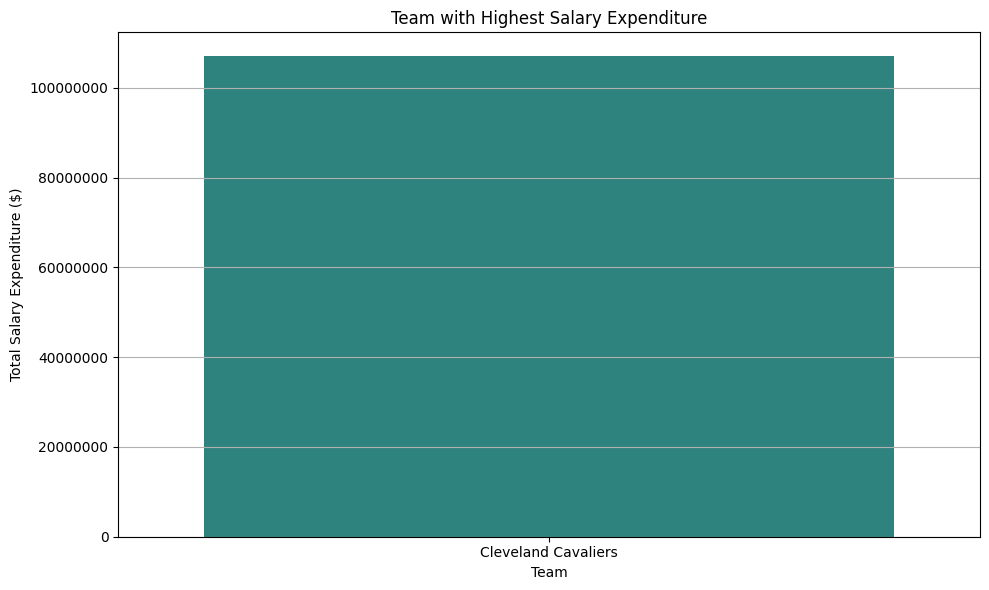

In [22]:
# Visualize the team with the highest salary expenditure
plt.figure(figsize=(10, 6))
sns.barplot(x=[highest_team_expenditure], y=[highest_team_salary], hue=[highest_team_expenditure], palette='viridis', legend=False)
plt.title('Team with Highest Salary Expenditure')
plt.xlabel('Team')
plt.ylabel('Total Salary Expenditure ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

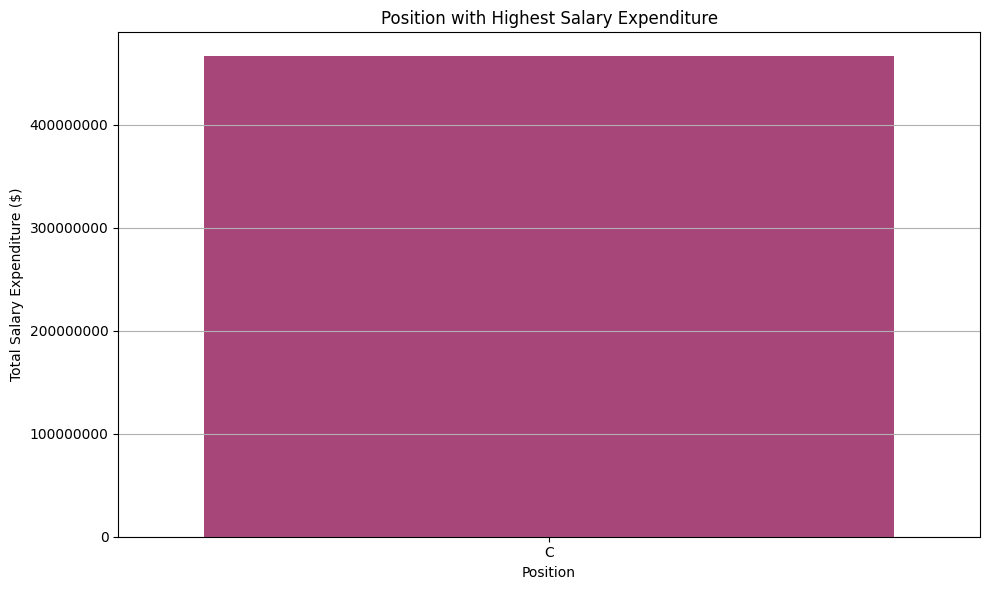

In [23]:
# Visualize the position with the highest salary expenditure
plt.figure(figsize=(10, 6))
sns.barplot(x=[highest_position_expenditure], y=[highest_position_salary], hue=[highest_position_expenditure], palette='magma', legend=False)
plt.title('Position with Highest Salary Expenditure')
plt.xlabel('Position')
plt.ylabel('Total Salary Expenditure ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Data Story: ABC Company Employee Dataset Analysis

This report provides a comprehensive analysis of the ABC Company employee dataset, covering preprocessing, distribution analysis, salary expenditure insights, and age-salary correlation.

### 1. Employee Distribution by Team and Position
- The company's employee distribution across teams shows some variation, with 'New Orleans Pelicans' having the highest number of employees (19) and 'Orlando Magic' and 'Minnesota Timberwolves' having the lowest (14 each). This suggests a slightly uneven distribution, which could be due to various factors such as team size requirements or departmental needs.
- Position-wise, 'SG' (Shooting Guard) and 'PF' (Power Forward) are the most common positions with 102 and 100 employees respectively, while 'C' (Center) is the least common with 79 employees. This indicates a higher emphasis or need for specific roles within the company structure.

### 2. Predominant Age Group
- The predominant age group among employees is **'25-34'**, accounting for 272 out of 458 employees. The '18-24' age group is also significant with 154 employees. This suggests a relatively young workforce, with a strong concentration of employees in their mid-twenties to early thirties. There are fewer employees in the older age brackets ('35-44' having 32 employees, and '45-54', '55-64', '65+' having zero employees).

### 3. Highest Salary Expenditure
- **Team with Highest Salary Expenditure:** The 'Cleveland Cavaliers' team has the highest total salary expenditure, amounting to $106,988,689.00.

 This could indicate a larger team, higher-paid individuals within the team, or a combination of both.
Position with Highest Salary Expenditure: The 'C' (Center) position has the highest total salary expenditure, totaling $466,377,332.00. Despite being the least common position in terms of employee count, it commands the highest overall salary, suggesting that individuals in this role are, on average, the highest-paid employees.

### 4. Age and Salary Correlation
- The correlation coefficient between 'Age' and 'Salary' is approximately **0.21**. This indicates a weak positive correlation. While there's a slight tendency for salary to increase with age, it's not a strong relationship, suggesting that other factors (such as position, performance, or team) play a more significant role in determining an employee's salary within the ABC Company. The scatter plot visually confirms this, showing a wide spread of salaries across different age groups, particularly for the younger demographics.